# 06 — Comparación de rendimiento

## Objetivo

Comparar experimentalmente la implementación secuencial frente
a la implementación paralela.

Se medirán:

- Tiempo de ejecución.
- Speedup.
- Eficiencia.
- Comportamiento frente al número de escenarios.
- Comportamiento frente al número de procesos.

Los resultados se obtendrán mediante benchmarks reales.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from src.data.loader import load_csv

from src.simulation.model import (
    NormalReturnModel,
)

from src.simulation.sequential import (
    SimulationConfig,
    simulate_sequential_final_values,
)

from src.simulation.parallel import (
    simulate_parallel_final_values,
)

from src.simulation.benchmark import (
    benchmark_simulation,
)

In [4]:
PROCESSED_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "sp500_returns.csv"
)

returns_data = load_csv(
    PROCESSED_DATA_PATH
)

mean_return = (
    returns_data["log_return"].mean()
)

volatility = (
    returns_data["log_return"].std()
)

model = NormalReturnModel(
    mean=mean_return,
    volatility=volatility,
)

In [5]:
HORIZON = 252
INITIAL_VALUE = 100.0
SEED = 42

SCENARIO_COUNTS = [
    10_000,
    100_000,
    1_000_000,
]

CPU_COUNT = (
    os.cpu_count() or 1
)

print(
    f"CPU lógicos disponibles: {CPU_COUNT}"
)

CPU lógicos disponibles: 4


In [7]:
WORKER_COUNTS = [
    2,
    4,
]

In [8]:
sequential_results = []

for scenario_count in SCENARIO_COUNTS:

    config = SimulationConfig(
        scenarios=scenario_count,
        horizon=HORIZON,
        initial_value=INITIAL_VALUE,
        seed=SEED,
    )

    result = benchmark_simulation(
        simulation_function=lambda config=config: (
            simulate_sequential_final_values(
                model=model,
                config=config,
            )
        ),
        scenarios=scenario_count,
    )

    sequential_results.append(
        {
            "mode": "sequential",
            "scenarios": scenario_count,
            "workers": 1,
            "elapsed_seconds": (
                result.elapsed_seconds
            ),
        }
    )

    print(
        f"Sequential | "
        f"{scenario_count:,} | "
        f"{result.elapsed_seconds:.4f}s"
    )

Sequential | 10,000 | 0.1347s
Sequential | 100,000 | 0.8757s
Sequential | 1,000,000 | 8.2438s


In [9]:
parallel_results = []

for scenario_count in SCENARIO_COUNTS:

    for workers in WORKER_COUNTS:

        config = SimulationConfig(
            scenarios=scenario_count,
            horizon=HORIZON,
            initial_value=INITIAL_VALUE,
            seed=SEED,
        )

        result = benchmark_simulation(
            simulation_function=(
                lambda config=config, workers=workers: (
                    simulate_parallel_final_values(
                        model=model,
                        config=config,
                        workers=workers,
                    )
                )
            ),
            scenarios=scenario_count,
        )

        parallel_results.append(
            {
                "mode": "parallel",
                "scenarios": scenario_count,
                "workers": workers,
                "elapsed_seconds": (
                    result.elapsed_seconds
                ),
            }
        )

        print(
            f"Parallel | "
            f"{scenario_count:,} | "
            f"{workers} workers | "
            f"{result.elapsed_seconds:.4f}s"
        )

Parallel | 10,000 | 2 workers | 0.4092s
Parallel | 10,000 | 4 workers | 0.6587s
Parallel | 100,000 | 2 workers | 1.1313s
Parallel | 100,000 | 4 workers | 1.3948s
Parallel | 1,000,000 | 2 workers | 6.2146s
Parallel | 1,000,000 | 4 workers | 4.0530s


In [10]:
results = pd.DataFrame(
    sequential_results
    + parallel_results
)

results

,mode,scenarios,workers,elapsed_seconds
0,sequential,10000,1,0.134702
1,sequential,100000,1,0.875660
2,sequential,1000000,1,8.243824
3,parallel,10000,2,0.409243
4,parallel,10000,4,0.658740
5,parallel,100000,2,1.131323
6,parallel,100000,4,1.394818
7,parallel,1000000,2,6.214625
8,parallel,1000000,4,4.052976


In [11]:
sequential_times = (
    results[
        results["mode"] == "sequential"
    ]
    .set_index("scenarios")[
        "elapsed_seconds"
    ]
)

sequential_times

scenarios
10000      0.134702
100000     0.875660
1000000    8.243824
Name: elapsed_seconds, dtype: float64

In [12]:
results["speedup"] = results.apply(
    lambda row: (
        sequential_times.loc[
            row["scenarios"]
        ]
        / row["elapsed_seconds"]
    ),
    axis=1,
)

results

,mode,scenarios,workers,elapsed_seconds,speedup
0,sequential,10000,1,0.134702,1.000000
1,sequential,100000,1,0.875660,1.000000
2,sequential,1000000,1,8.243824,1.000000
3,parallel,10000,2,0.409243,0.329150
4,parallel,10000,4,0.658740,0.204485
5,parallel,100000,2,1.131323,0.774014
6,parallel,100000,4,1.394818,0.627795
7,parallel,1000000,2,6.214625,1.326520
8,parallel,1000000,4,4.052976,2.034017


In [13]:
results["efficiency"] = results.apply(
    lambda row: (
        row["speedup"]
        / row["workers"]
        if row["mode"] == "parallel"
        else 1.0
    ),
    axis=1,
)

results

,mode,scenarios,workers,elapsed_seconds,speedup,efficiency
0,sequential,10000,1,0.134702,1.000000,1.000000
1,sequential,100000,1,0.875660,1.000000,1.000000
2,sequential,1000000,1,8.243824,1.000000,1.000000
3,parallel,10000,2,0.409243,0.329150,0.164575
4,parallel,10000,4,0.658740,0.204485,0.051121
5,parallel,100000,2,1.131323,0.774014,0.387007
6,parallel,100000,4,1.394818,0.627795,0.156949
7,parallel,1000000,2,6.214625,1.326520,0.663260
8,parallel,1000000,4,4.052976,2.034017,0.508504


In [14]:
COMPARISON_PATH = (
    PROJECT_ROOT
    / "results"
    / "benchmarks"
    / "performance_comparison.csv"
)

COMPARISON_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

results.to_csv(
    COMPARISON_PATH,
    index=False,
)

print(
    f"Resultados guardados en:\n"
    f"{COMPARISON_PATH}"
)

Resultados guardados en:
c:\Users\REYES\OneDrive\Desktop\9noSemestre\programacion paralela\analisis riesgo montecarlo\results\benchmarks\performance_comparison.csv


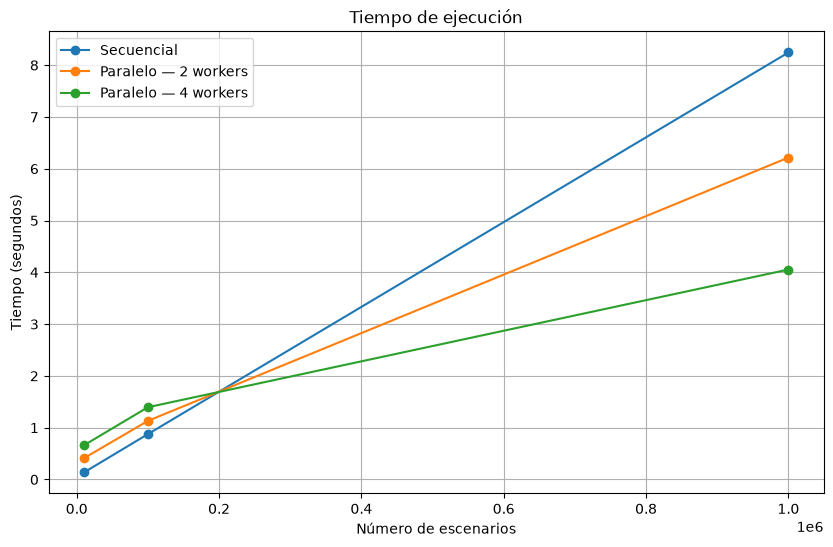

In [15]:
plt.figure(figsize=(10, 6))

sequential = results[
    results["mode"] == "sequential"
]

plt.plot(
    sequential["scenarios"],
    sequential["elapsed_seconds"],
    marker="o",
    label="Secuencial",
)

for workers in WORKER_COUNTS:

    parallel = results[
        (results["mode"] == "parallel")
        & (results["workers"] == workers)
    ]

    plt.plot(
        parallel["scenarios"],
        parallel["elapsed_seconds"],
        marker="o",
        label=f"Paralelo — {workers} workers",
    )

plt.title(
    "Tiempo de ejecución"
)

plt.xlabel(
    "Número de escenarios"
)

plt.ylabel(
    "Tiempo (segundos)"
)

plt.legend()

plt.grid(True)

plt.show()

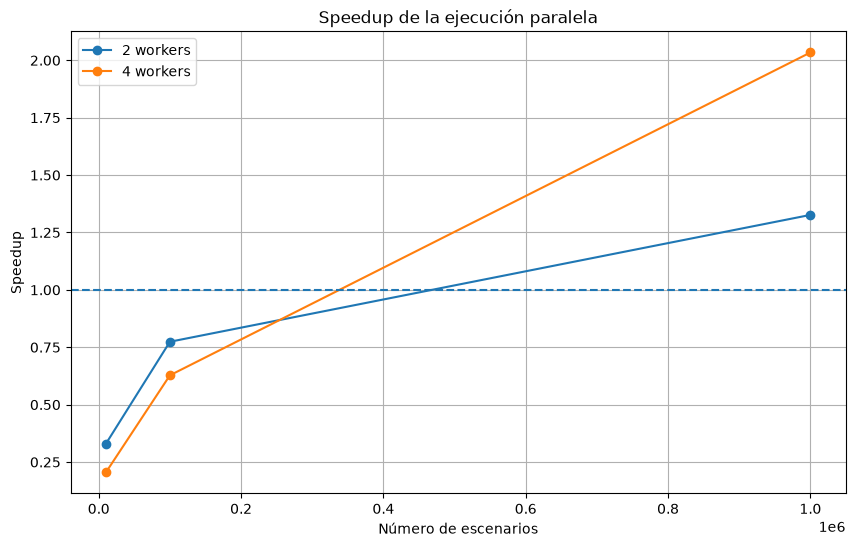

In [16]:
parallel = results[
    results["mode"] == "parallel"
]

plt.figure(figsize=(10, 6))

for workers in WORKER_COUNTS:

    subset = parallel[
        parallel["workers"] == workers
    ]

    plt.plot(
        subset["scenarios"],
        subset["speedup"],
        marker="o",
        label=f"{workers} workers",
    )

plt.axhline(
    1.0,
    linestyle="--",
)

plt.title(
    "Speedup de la ejecución paralela"
)

plt.xlabel(
    "Número de escenarios"
)

plt.ylabel(
    "Speedup"
)

plt.legend()

plt.grid(True)

plt.show()

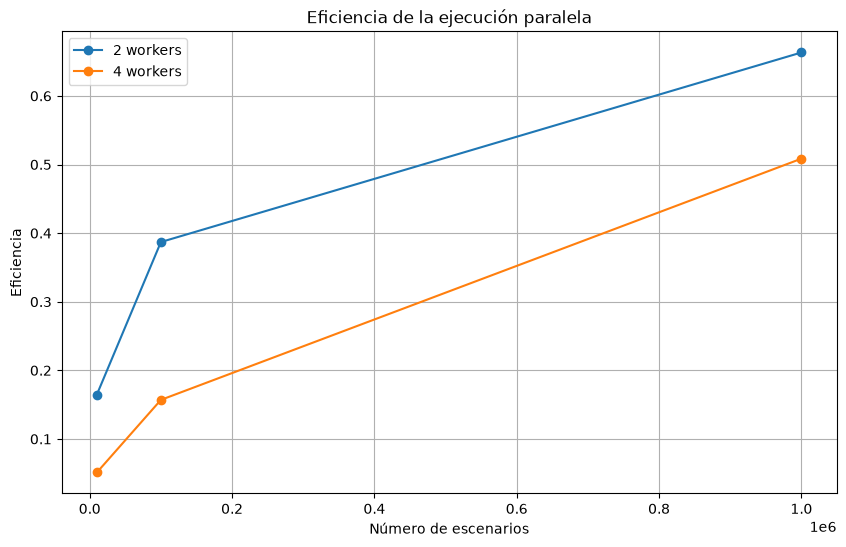

In [17]:
plt.figure(figsize=(10, 6))

for workers in WORKER_COUNTS:

    subset = parallel[
        parallel["workers"] == workers
    ]

    plt.plot(
        subset["scenarios"],
        subset["efficiency"],
        marker="o",
        label=f"{workers} workers",
    )

plt.title(
    "Eficiencia de la ejecución paralela"
)

plt.xlabel(
    "Número de escenarios"
)

plt.ylabel(
    "Eficiencia"
)

plt.legend()

plt.grid(True)

plt.show()

In [18]:
best_result = (
    parallel
    .sort_values(
        "elapsed_seconds"
    )
    .iloc[0]
)

print(
    "Mejor resultado paralelo observado:"
)

print(
    f"Escenarios: "
    f"{int(best_result['scenarios']):,}"
)

print(
    f"Workers: "
    f"{int(best_result['workers'])}"
)

print(
    f"Tiempo: "
    f"{best_result['elapsed_seconds']:.4f} s"
)

print(
    f"Speedup: "
    f"{best_result['speedup']:.4f}"
)

print(
    f"Eficiencia: "
    f"{best_result['efficiency']:.4f}"
)

Mejor resultado paralelo observado:
Escenarios: 10,000
Workers: 2
Tiempo: 0.4092 s
Speedup: 0.3291
Eficiencia: 0.1646


# Conclusiones preliminares

1. La implementación secuencial proporciona una línea base
   experimental para evaluar el comportamiento de la versión
   paralela.

2. La ejecución paralela distribuye los escenarios independientes
   entre múltiples procesos, permitiendo estudiar el efecto del
   paralelismo sobre el tiempo de ejecución.

3. El beneficio del paralelismo depende del tamaño del problema,
   del número de procesos y del costo asociado a la creación y
   comunicación entre procesos.

Los resultados concretos deben interpretarse a partir de los
benchmarks obtenidos en el equipo utilizado para el experimento.